In [29]:
import camelot
import pdfplumber
import pandas as pd
import tabula
from pdfplumber.utils import extract_text, get_bbox_overlap, obj_to_bbox
from pdf_table_to_dataframe import *

In [24]:
pwd

'C:\\Users\\et3\\PycharmProjects\\lab_analysis'

In [31]:
#pdf_file  = 'bachtochem/bactochem.pdf'
pdf_file  = 'ALS/check_1.pdf'
tables = camelot.read_pdf(pdf_file,flavor='stream', table_areas=['220,40,600,420'])
tables = camelot.read_pdf(pdf_file,flavor='stream', pages='2',table_areas=['220,40,600,420'])
#tables_2_3 = camelot.read_pdf(pdf_file,pages='2,3', flavor='stream', table_areas=['220,50,600,800'])
#tables_4 = camelot.read_pdf(pdf_file,pages='4', flavor='stream', table_areas=['220,200,600,800'])
df = tables[0].df
#df_2 = tables_2_3[0].df
#df_3 = tables_2_3[1].df
#df_4 = tables_4[0].df

C:\Users\et3\AppData\Local\Temp\ipykernel_17244\1227982490.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  camelot.plot(tables[0], 'grid').show()


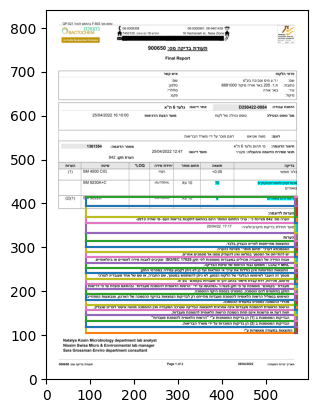

In [26]:
camelot.plot(tables[0], 'grid').show()

In [27]:
df

,0,1
0,cfu/100mL\n \nX≤ 10\n9,םייתאוצ םימרופילוק
1,:המגודל תורעה,
2,-2013 היתש ימ- םעה תואירב תונקתל םאתהב םניה רת...,•
3,25/04/22 17:17\n:היגולויבורקימ תוקידב תליחת דעומ,
4,תורעה,
5,.דבלב קדבנה טירפל תוסחייתמ תואצותה,•
6,".הרעהכ תניוצמ ""רתומ םוחת"" יכרעל אתכמסאה",•
7,.םירחא םיכמסמ לא ונממ קיתעהל ןיאו ואולמב ךמסמה...,•
8,.םיימואלניב וא םיימואל הדימ תובאל םיביקעו ISO...,
9,.הקידבה תטיש לש תומיכה לובג ועמשמ : LOQ = MRL,


In [176]:
df_all = pd.concat([df,df_2,df_3,df_4])
df_all.drop(df_all.columns[3], axis=1,inplace=True)
df_all.columns  = list(df_all.iloc[0])
df_all.drop(index=0, axis=0,inplace=True)

In [173]:
df_all.to_csv('almog.csv', encoding='utf-8-sig', index=False)

In [ ]:
from image_extractor import *
from identifier import predict_logo
from tensorflow.keras.models import load_model

model = load_model('lab_logo_classifier.h5')
# Get image locations only (lightweight)
#images = get_image_locations(pdf_file)
#images
#for img in images:
#    print(f"Page {img['page_number']}: {img['width']}x{img['height']} image")

# Full extraction with image data
images_with_data = extract_images_hybrid_method(pdf_file)
for img in images_with_data:
    predict_logo(model, img, [1,2,3])     
     #     print(f"Page {img.page_number}: {img}")
     #     img.save_image()  # Save to file

In [16]:
img

{'page_number': 11,
 'image_index': 0,
 'x0': 56.7,
 'top': 35.44999999999993,
 'x1': 114.265,
 'bottom': 91.44999999999993,
 'width': 57.565,
 'height': 56.0,
 'object_type': 'image'}